In [1]:
from pathlib import Path
import yaml
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn

import matplotlib.pyplot as plt

data_file = 'data/etalon_snr_over_time.csv'
t = Table.read(data_file, format='ascii.csv')
print(len(t))
t = t[t['READSPED'] == 'regular']
print(len(t))
t = t[t['MJD-OBS'] > 59750]
print(len(t))

119477
118205
118187


In [2]:
# KPFERA 1.0 is before SM1
SM1start = Time('2024-02-03')
SM1end = Time('2024-02-23')
# KPFERA 2.0 is between SM1 and SM2
SM2start = Time('2024-10-31')
SM2end = Time('2024-11-20')
# KPFERA 2.5/2.6 is between SM2 and SM3
SM3start = Time('2025-03-28')
SM3end = Time('2025-04-23')
# KPFERA 3.0 is between SM3 and SM4
SM4start = Time('2025-08-31')
SM4end = Time('2025-10-27')
# KPFERA 4.0 is after SM4

KPFEra = MaskedColumn(data=['?']*len(t), mask=np.zeros(len(t), dtype=bool), name='KPFEra', dtype='a3')

KPFEra[(t['MJD-OBS'] > 59823) & (t['MJD-OBS'] < SM1start.mjd)] = '1.0'
KPFEra[(t['MJD-OBS'] > SM1end.mjd) & (t['MJD-OBS'] < SM2start.mjd)] = '2.0'
KPFEra[(t['MJD-OBS'] > SM2end.mjd) & (t['MJD-OBS'] < SM3start.mjd)] = '2.5'
KPFEra[(t['MJD-OBS'] > SM3end.mjd) & (t['MJD-OBS'] < SM4start.mjd)] = '3.0'
KPFEra[(t['MJD-OBS'] > SM4end.mjd)] = '4.0'
KPFEra.mask = KPFEra == '?'
t.add_column(KPFEra)

In [4]:
ZPfile = Path('data/InstrumentZeroPoints.yaml')
with open(ZPfile, 'r') as f:
    ZeroPoint = yaml.safe_load(f)
ZeroPoint

{'452': 13.664362089856091,
 '548': 14.964690898633878,
 '652': 15.329155098901115,
 '747': 15.466755734095996,
 '852': 15.073233551565435}

In [5]:
wavs = ZeroPoint.keys()

In [6]:
for wav in wavs:
    # Magnitude in Science Trace
    magSC = ZeroPoint[wav] - np.log10(t[f'SNRSC{wav}']**2 / t['EXPTIME'])
    t.add_column(MaskedColumn(magSC, name=f'magSC{wav}'))
    t[f'SNRSC{wav}'].mask = t[f'SNRSC{wav}'].mask | (t[f'SNRSC{wav}'] <= 0)
    t[f'magSC{wav}'].mask = t[f'SNRSC{wav}'].mask
    # Magnitude in Calibration Trace
    magCL = ZeroPoint[wav] - np.log10(t[f'SNRCL{wav}']**2 / t['EXPTIME'])
    t.add_column(MaskedColumn(magCL, name=f'magCL{wav}'))
    t[f'SNRCL{wav}'].mask = t[f'SNRCL{wav}'].mask | (t[f'SNRCL{wav}'] <= 0)
    t[f'magCL{wav}'].mask = t[f'SNRCL{wav}'].mask

/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_27719/3761042522.py:3: RuntimeWarning: divide by zero encountered in log10
  magSC = ZeroPoint[wav] - np.log10(t[f'SNRSC{wav}']**2 / t['EXPTIME'])
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_27719/3761042522.py:8: RuntimeWarning: divide by zero encountered in log10
  magCL = ZeroPoint[wav] - np.log10(t[f'SNRCL{wav}']**2 / t['EXPTIME'])


In [9]:
days = list(set(mjd))
day_magsSC = {}
day_magsCL = {}
day_counts = []
for w,wav in enumerate(wavs):
    if wav not in day_magsSC.keys():
        day_magsSC[wav] = []
        day_magsCL[wav] = []
    for j,day in enumerate(days):
        wday = np.where((mjd == day))
        day_magsSC[wav].append(np.median(t[f'magSC{wav}'][wday]))
        day_magsCL[wav].append(np.median(t[f'magCL{wav}'][wday]))
        if w == 0: day_counts.append(len(t[f'magSC{wav}'][wday]))

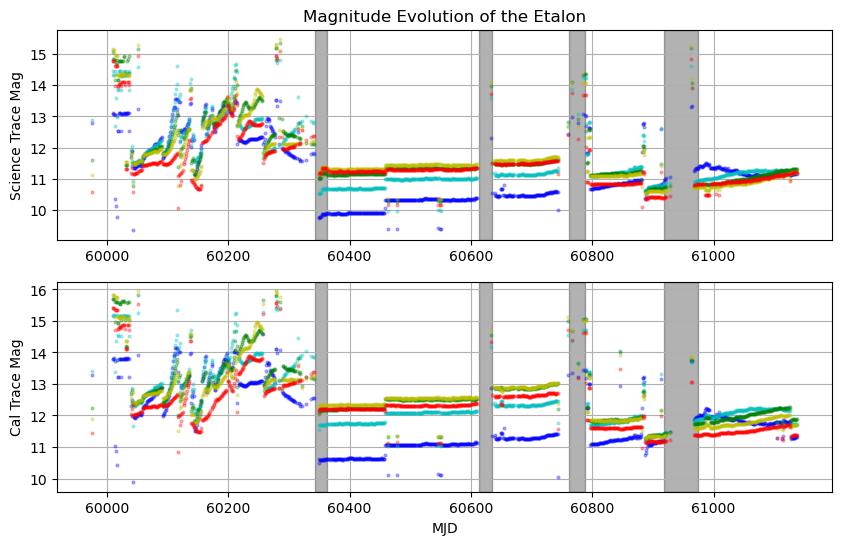

In [17]:
mjd = np.array([int(d) for d in t['MJD-OBS']])

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.title(f'Magnitude Evolution of the Etalon')
for w,wav in enumerate(wavs):
    color = ['b', 'c', 'g', 'y', 'r'][w]
    plt.plot(days, day_magsSC[wav], f'{color}o', alpha=0.3, ms=2, label=f'{wav}nm')
plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
plt.ylabel('Science Trace Mag')
plt.grid()
# plt.legend(loc='best')

plt.subplot(2,1,2)
for w,wav in enumerate(wavs):
    color = ['b', 'c', 'g', 'y', 'r'][w]
    plt.plot(days, day_magsCL[wav], f'{color}o', alpha=0.3, ms=2, label=f'{wav}nm')
plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
plt.xlabel('MJD')
plt.ylabel('Cal Trace Mag')
plt.grid()
# plt.legend(loc='best')

plt.show()